In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.curve_snapshot import CurveSnapshot
from src.curves.bootstrap.bootstrap_engine import BootstrapCurveEngine
from src.curves.projection_curve import ProjectionCurve
from src.curves.zero_curve import ZeroCurve
from src.curves.simulator.hull_white_2factor import HullWhite2FactorSimulator
from src.curves.simulator.hull_white_2factor_pricer import HullWhite2FactorPricer
from src.curves.calibrator.pca_factor_extractor import PCAFactorExtractor
from src.curves.calibrator.ou_factor_calibrator import OUFactorCalibrator

from src.pricing.hull_white_2factor_swap_pricer import HullWhite2FactorSwapPricer

from src.risk.exposure.stochastic_exposure_engine_2factor import MonteCarloExposureEngine2Factor

from src.instruments.instrument_builder import InstrumentBuilder

from src.trades.interest_rate_swap import InterestRateSwap

In [2]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

# downloading swap curves
swap_loader = MarketLoader()
swap_curves = swap_loader.swap_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..
usd_ois curve dataset already downloaded..
eur_ois curve dataset already downloaded..


In [3]:
# yield curve history
curve_history = market_curves['treasury']
curve_history = curve_history / 100

In [4]:
### create curve snapshots
# SOFR snapshot
sofr_df = market_curves['sofr']

latest_date = sofr_df.index[-1]
latest_sofr_curve = sofr_df.iloc[-1]

sofr_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'sofr',
    as_of_date = latest_date,
    curve_row = latest_sofr_curve
)

# Futures snapshot
future_df = market_curves['futures']
latest_futures_curve = future_df.iloc[-1]

futures_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'futures',
    as_of_date = latest_date,
    curve_row = latest_futures_curve
)

# OIS snapshot
ois_df = swap_curves['usd_ois']

latest_swap_date = ois_df.index[-1]
latest_swap_curve = ois_df.iloc[-1]

ois_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'usd_ois',
    as_of_date = latest_swap_date,
    curve_row = latest_swap_curve
)

In [5]:
### create instruments from curve snapshot
# deposits
deposit_instruments = InstrumentBuilder.build_deposit_instruments(snapshot = sofr_snapshot)

# futures
future_instruments = InstrumentBuilder.build_future_instruments(snapshot = futures_snapshot)

# ois
ois_instruments = InstrumentBuilder.build_ois_instruments(snapshot = ois_snapshot)

### discount, projection and zero curve builder
# bootstrapping engine for generating the discount curve
all_instruments = deposit_instruments + future_instruments + ois_instruments

engine = BootstrapCurveEngine()

discount_curve = engine.bootstrap(
    snapshot = sofr_snapshot,
    instruments = all_instruments
)

# projection curve
projection_curve = ProjectionCurve(discount_curve = discount_curve)

# zero curve
zero_curve = ZeroCurve(discount_curve = discount_curve)

In [6]:
# sample IRS trade objects
IR_swap = InterestRateSwap(
    notional = 1_000_000,
    maturity = 3.0,
    fixed_rate = 3.40,
    pay_fixed = True
)

In [7]:
### PCA factor extractor
# initialize PCA factor extractor
pca = PCAFactorExtractor(n_factors = 2)

# fitting PCAs to historical yield changes and projecting onto factors
factor_history = pca.fit_transform(yield_curve_history = curve_history)

# explained variance of PCA factors
variance_report = pca.variance_report()
variance_report

,Component,ExplainedVariance,CumulativeVariance
0,PC1,0.648120,0.648120
1,PC2,0.145519,0.793639
2,PC3,0.116726,0.910365
3,PC4,0.051388,0.961753
4,PC5,0.018744,0.980497
5,PC6,0.009297,0.989794
6,PC7,0.007823,0.997616
7,PC8,0.002384,1.000000


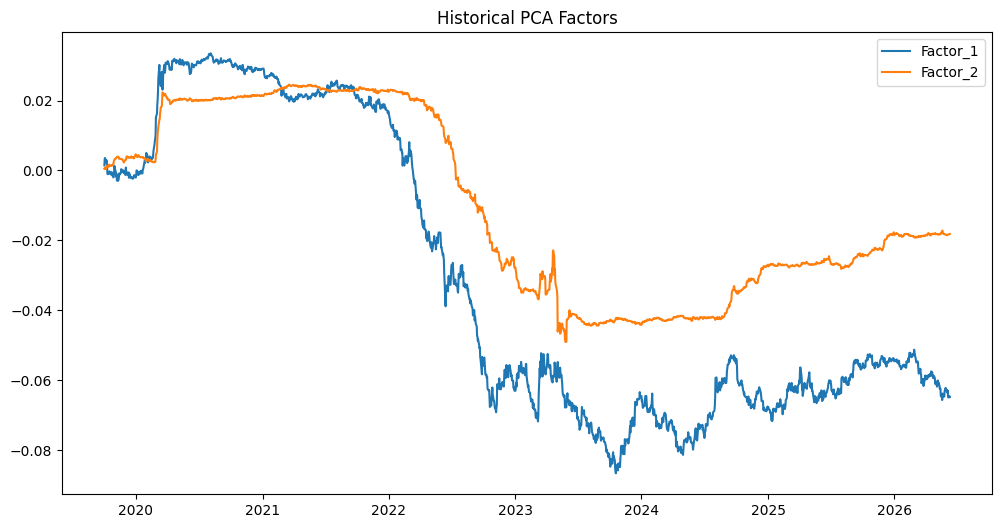

In [8]:
# plot PCA factors
plt.figure(figsize = (12, 6))

plt.plot(factor_history.index, factor_history['Factor_1'], label = 'Factor_1')
plt.plot(factor_history.index, factor_history['Factor_2'], label = 'Factor_2')
plt.title('Historical PCA Factors')
plt.legend(loc = 'best')
plt.show()

In [9]:
# factor loadings
factor_loadings = pca.get_factor_loadings()
factor_loadings.index = curve_history.columns
factor_loadings 

,Factor1,Factor2
1M,-0.040649,-0.955008
3M,-0.117023,-0.158067
6M,-0.193153,-0.125755
1Y,-0.329788,-0.108476
2Y,-0.470490,-0.033994
5Y,-0.509812,0.062522
10Y,-0.463166,0.107123
30Y,-0.377880,0.137305


In [10]:
# Ornstein-Uhlenbeck factor calibration
ou_calibrator = OUFactorCalibrator(dt = 1/252)

# calibrate HW 2-factor model parameters
hw2f_params = ou_calibrator.calibrate_hw2f(factor_history = factor_history)
hw2f_params

{'a': 0.0002520001260073305,
 'b': 0.02005720669758981,
 'sigma1': 0.01872219167004199,
 'sigma2': 0.008873582137841807,
 'rho': -0.0006194015774373465}

In [11]:
### HW 2-factor simulator using calibrated HW 2-factor model parameters
# short rate
r0 = zero_curve.get_zero_rate(maturity = 0.25)

# simulator engine
hw_simulator = HullWhite2FactorSimulator(
    r0 = r0,
    a = hw2f_params['a'],
    b = hw2f_params['b'],
    sigma1 = hw2f_params['sigma1'],
    sigma2 = hw2f_params['sigma2'],
    rho = hw2f_params['rho'],
    random_seed = 2
)

# hw pricer
hw_pricer = HullWhite2FactorPricer(
    zero_curve = zero_curve,
    a = hw2f_params['a'],
    b = hw2f_params['b'],
    sigma1 = hw2f_params['sigma1'],
    sigma2 = hw2f_params['sigma2'],
    rho = hw2f_params['rho']
)

# hw 2-factor swap pricer
hw_swap_pricer = HullWhite2FactorSwapPricer(hw_pricer = hw_pricer)

# exposure engine
hw2f_mc_engine = MonteCarloExposureEngine2Factor(
    pricer = hw_swap_pricer,
    simulator = hw_simulator
)

# exposure report
exposure_report = hw2f_mc_engine.mc_exposure_report(
    swap = IR_swap,
    percentile = 95.0,
    n_paths = 250,
    steps_per_year = 4
)
exposure_report

,Times,EE,ENE,PFE_95%,EffectiveEE
0,0.00,11168.934638,-0.000000,11168.934638,11168.934638
1,0.25,16801.976644,8273.008498,54678.769337,16048.643484
2,0.50,18362.890406,12925.744705,70429.289907,18925.027304
3,0.75,18570.460795,15078.274207,72028.366537,18925.027304
4,1.00,17128.079671,16050.386521,74171.690184,18925.027304
5,1.25,16949.382430,16130.949460,76748.582517,18925.027304
6,1.50,16673.690143,14922.810901,70522.690639,18925.027304
7,1.75,14110.344866,13555.117201,59103.832006,18925.027304
8,2.00,12064.712996,11724.815974,46297.555013,18925.027304
9,2.25,9042.733286,8933.581518,38739.940642,18925.027304
